# Project 11 -- Lukas Anell

In [1]:
# /anvil/projects/tdm/data/zillow/State_time_series.csv

## Question 1

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
myDF = pd.read_csv("/anvil/projects/tdm/data/zillow/State_time_series.csv")
myDF.head()

,Date,RegionName,DaysOnZillow_AllHomes,InventorySeasonallyAdjusted_AllHomes,InventoryRaw_AllHomes,MedianListingPricePerSqft_1Bedroom,MedianListingPricePerSqft_2Bedroom,MedianListingPricePerSqft_3Bedroom,MedianListingPricePerSqft_4Bedroom,MedianListingPricePerSqft_5BedroomOrMore,...,ZHVI_BottomTier,ZHVI_CondoCoop,ZHVI_MiddleTier,ZHVI_SingleFamilyResidence,ZHVI_TopTier,ZRI_AllHomes,ZRI_AllHomesPlusMultifamily,ZriPerSqft_AllHomes,Zri_MultiFamilyResidenceRental,Zri_SingleFamilyResidenceRental
0,1996-04-30,Alabama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,45600.0,99500.0,79500.0,79000.0,140200.0,NaN,NaN,NaN,NaN,NaN
1,1996-04-30,Arizona,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,67100.0,78900.0,103600.0,107500.0,168700.0,NaN,NaN,NaN,NaN,NaN
2,1996-04-30,Arkansas,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,38400.0,70300.0,64400.0,64500.0,115200.0,NaN,NaN,NaN,NaN,NaN
3,1996-04-30,California,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,95100.0,136100.0,157900.0,162000.0,270600.0,NaN,NaN,NaN,NaN,NaN
4,1996-04-30,Colorado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,82700.0,99400.0,128100.0,133600.0,209300.0,NaN,NaN,NaN,NaN,NaN


In [4]:
myDF['Date'] = pd.to_datetime(myDF['Date'])
myDF['Date'].head()

0   1996-04-30
1   1996-04-30
2   1996-04-30
3   1996-04-30
4   1996-04-30
Name: Date, dtype: datetime64[ns]

In [5]:
selected_regions = ["Indiana", "Tennessee", "Utah", "NewHampshire"]

In [6]:
myDF_selected_regions = myDF[myDF['RegionName'].isin(selected_regions)]
myDF_grouped = myDF_selected_regions.groupby(["Date", "RegionName"], as_index=False)
myDF_grouped = myDF_grouped.agg(avg_price=("MedianListingPrice_AllHomes", "mean"))

In [7]:
myDF_grouped.head()

,Date,RegionName,avg_price
0,1996-04-30,Indiana,NaN
1,1996-04-30,NewHampshire,NaN
2,1996-04-30,Tennessee,NaN
3,1996-04-30,Utah,NaN
4,1996-05-31,Indiana,NaN


In [8]:
myDF_grouped.tail()

,Date,RegionName,avg_price
1039,2017-11-30,Utah,334890.0
1040,2017-12-31,Indiana,163000.0
1041,2017-12-31,NewHampshire,279900.0
1042,2017-12-31,Tennessee,224900.0
1043,2017-12-31,Utah,337500.0


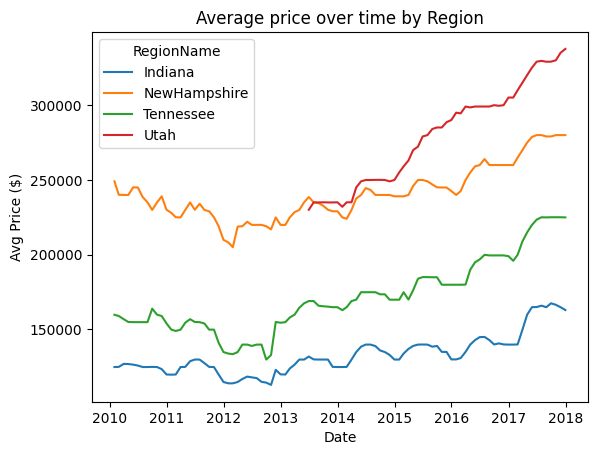

In [9]:
sns.lineplot(data=myDF_grouped, x="Date", y="avg_price", hue="RegionName")
plt.title("Average price over time by Region")
plt.xlabel("Date")
plt.ylabel("Avg Price ($)")
plt.show()

1.1: See above.

1.2: See above.

1.3: The line plot shows how every region follows the same general trend. It seems like there was a dip in housing prices during 2012-2013, and since then it has been increasing on average. Near the end of the graph, around the end of 2017, it shows the prices in some of the regions flattening out.

## Question 2

In [10]:
myDF["RegionName"].value_counts()

RegionName
Alabama               261
Arizona               261
Arkansas              261
California            261
Colorado              261
Connecticut           261
Delaware              261
Florida               261
Georgia               261
Hawaii                261
Idaho                 261
Illinois              261
Indiana               261
Iowa                  261
Kansas                261
Kentucky              261
Louisiana             261
Maine                 261
Maryland              261
Massachusetts         261
Michigan              261
Minnesota             261
Mississippi           261
Missouri              261
Nebraska              261
Nevada                261
NewHampshire          261
NewJersey             261
NewMexico             261
NewYork               261
NorthCarolina         261
Ohio                  261
Oklahoma              261
Oregon                261
Pennsylvania          261
RhodeIsland           261
SouthCarolina         261
Tennessee             261
T

In [11]:
myDF_cleaned = myDF.dropna(subset=['DaysOnZillow_AllHomes'])
myDF_cleaned["RegionName"].value_counts()

RegionName
Alabama               95
Alaska                95
Arizona               95
Arkansas              95
California            95
Colorado              95
Connecticut           95
Delaware              95
DistrictofColumbia    95
Florida               95
Georgia               95
Hawaii                95
Idaho                 95
Illinois              95
Indiana               95
Iowa                  95
Kansas                95
Kentucky              95
Louisiana             95
Maine                 95
Maryland              95
Massachusetts         95
Michigan              95
Minnesota             95
Mississippi           95
Missouri              95
Montana               95
Nebraska              95
Nevada                95
NewHampshire          95
NewJersey             95
NewMexico             95
NewYork               95
NorthCarolina         95
NorthDakota           95
Ohio                  95
Oklahoma              95
Oregon                95
Pennsylvania          95
RhodeIsland   

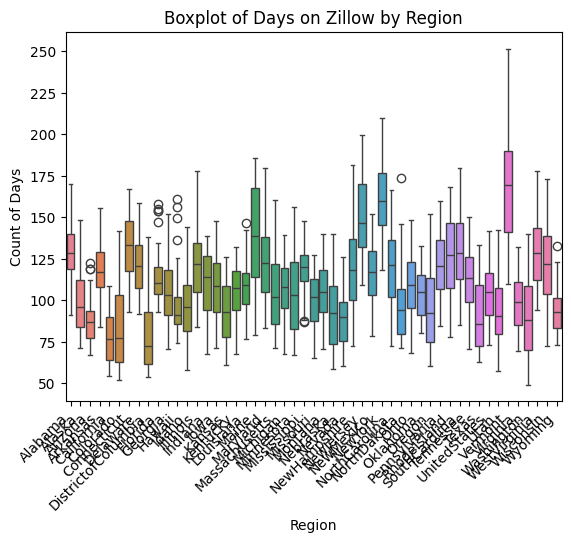

<Figure size 10000x10000 with 0 Axes>

In [12]:
sns.boxplot(data=myDF_cleaned, x="RegionName", y="DaysOnZillow_AllHomes", hue="RegionName")
plt.title("Boxplot of Days on Zillow by Region")
plt.xlabel("Region")
plt.ylabel("Count of Days")
plt.xticks(rotation=45, ha="right")
plt.figure(figsize=(100, 100))
plt.show()

2.1: See above.

2.2: See above.

2.3: I tried using the plt.figure() function like suggested but I feel like it didn't change anything at all.

## Question 3

In [13]:
the_northeast = ['Connecticut', 'Maine', 'Massachusetts', 'NewHampshire', 'NewJersey', 'NewYork', 'Pennsylvania', 'RhodeIsland', 'Vermont']
the_midwest = ['Illinois', 'Indiana', 'Iowa', 'Kansas', 'Michigan', 'Minnesota', 'Missouri', 'Nebraska', 'NorthDakota', 'Ohio', 'Wisconsin']
the_south = ['Alabama', 'Arkansas', 'Delaware', 'DistrictofColumbia', 'Florida', 'Georgia', 'Kentucky', 'Louisiana', 'Maryland', 'Mississippi', 'NorthCarolina', 'Oklahoma', 'SouthCarolina', 'Tennessee', 'Texas', 'Virginia', 'WestVirginia']
the_west = ['Alaska', 'Arizona', 'California', 'Colorado', 'Hawaii', 'Idaho', 'Montana', 'Nevada', 'NewMexico', 'Oregon', 'Utah', 'Washington', 'Wyoming']

In [14]:
conditions = [
    myDF_cleaned['RegionName'].isin(the_northeast),
    myDF_cleaned['RegionName'].isin(the_midwest),
    myDF_cleaned['RegionName'].isin(the_south),
    myDF_cleaned['RegionName'].isin(the_west)
]

In [15]:
choices = ["Northeast", "Midwest", "South", "West"]

In [16]:
myDF_cleaned["NewRegions"] = np.select(conditions, choices, default="Other")

/tmp/ipykernel_5837/1874668550.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  myDF_cleaned["NewRegions"] = np.select(conditions, choices, default="Other")


In [17]:
myDF_cleaned["NewRegions"].value_counts()

NewRegions
South        1615
West         1235
Midwest      1045
Northeast     855
Other          95
Name: count, dtype: int64

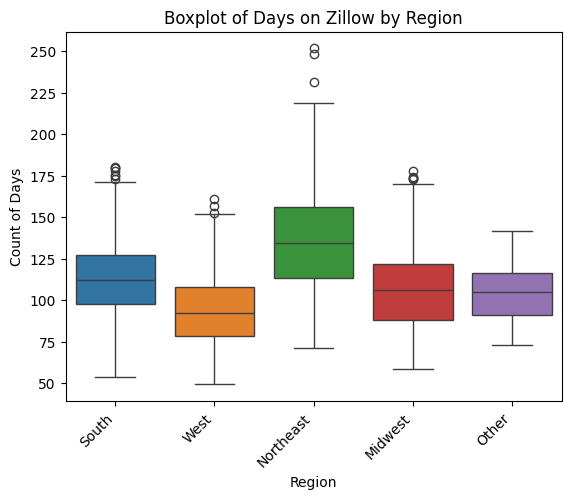

In [18]:
sns.boxplot(data=myDF_cleaned, x="NewRegions", y="DaysOnZillow_AllHomes", hue="NewRegions")
plt.title("Boxplot of Days on Zillow by Region")
plt.xlabel("Region")
plt.ylabel("Count of Days")
plt.xticks(rotation=45, ha="right")
plt.show()

3.1: See above.

3.2: See above.

3.3: As seen in the graph, The West has the lowest median, which I think makes sense because of the high demand for housing especially in California, Washington, etc. I would have expected the Northeast to be similar, but it seems like a few outliers are dragging the median up. I think this is likely because there are a few more expensive or harder to sell homes that would inevitably be harder to sell. The South and the Midwest are very similar to each other, which I would expect because to me they're very similar parts of the US (They probably are super different but I've never been to the South and haven't gotten around in the Midwest at all, so I'm not the best source of information for this).

## Question 4

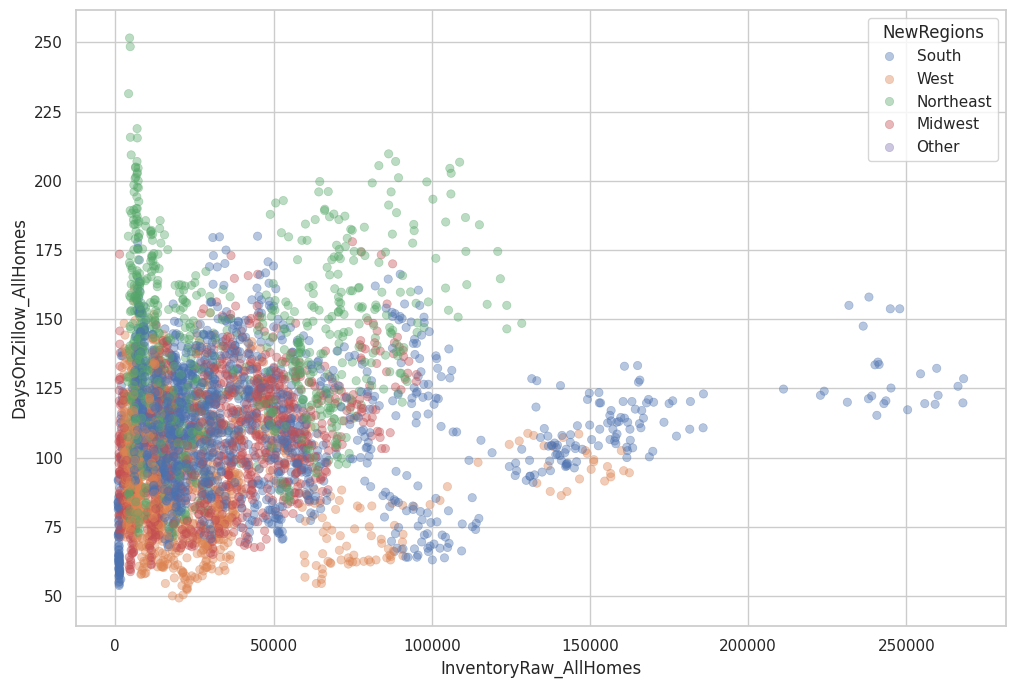

In [26]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=myDF_cleaned, 
    x="InventoryRaw_AllHomes", 
    y="DaysOnZillow_AllHomes", 
    hue="NewRegions", 
    alpha=0.4,
    edgecolor=None
)

plt.show()

4.1: `DaysOnZillow_AllHomes` represents the demand of homes in the market, while the `InventoryRaw_AllHomes` column represents the supply of homes in the market. They are most likely inversely related because if there are few homes, they will sell faster, and vice-versa.

4.2: See above.

4.3: Not labeling the axes or adding a legend, plotting the dots as solid points, using the same colors or shapes for different categories, or the other way around.

## Question 5

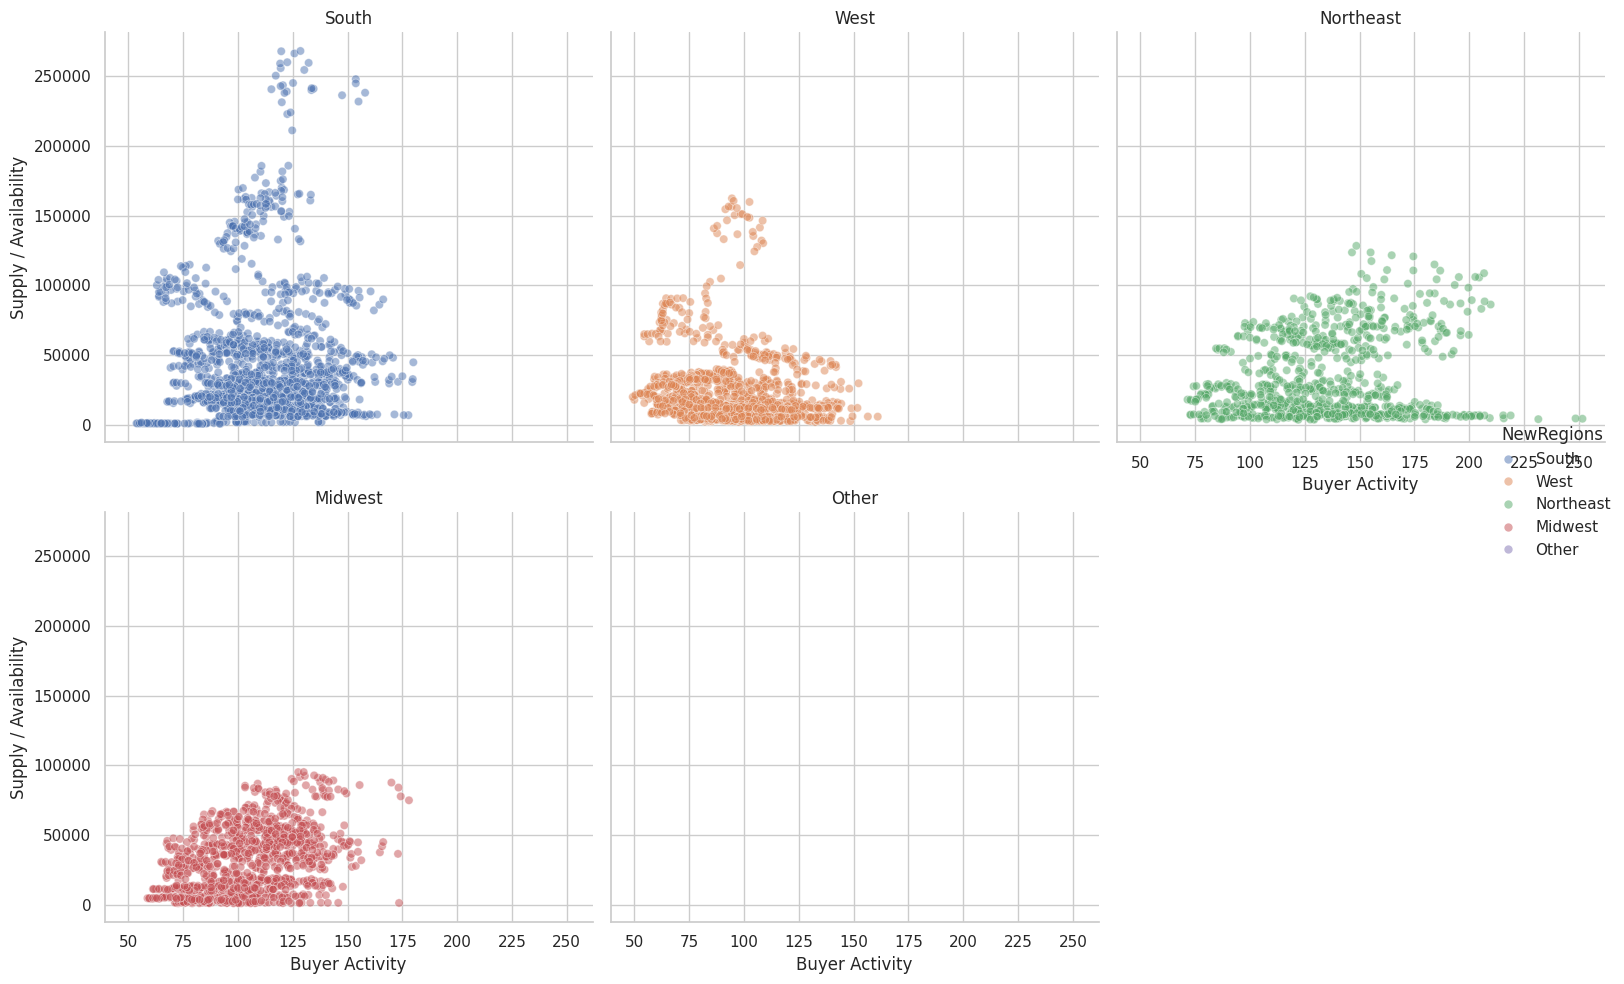

In [29]:
my_plots = sns.relplot(
    data=myDF_cleaned,
    x="DaysOnZillow_AllHomes", 
    y="InventoryRaw_AllHomes",
    hue="NewRegions",
    col="NewRegions",
    col_wrap=3,
    kind="scatter",
    alpha=0.5
)

my_plots.set_titles("{col_name}")
my_plots.set_axis_labels("Buyer Activity", "Supply / Availability")

plt.tight_layout()
plt.show()

5.1: See above.

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
